In [123]:
import pandas as pd
import numpy as np
from contextlib import contextmanager
from datetime import datetime
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
import polars as pl
import psutil
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Coinmetrics

In [124]:
# read data
df = pd.read_csv("../data/Coin Metrics/coinmetrics_btc.csv")
df["time"] = pd.to_datetime(df["time"])
df.head()

,time,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,...,ReferenceRateETH,ReferenceRateEUR,ReferenceRateUSD,SplyCur,SplyExNtv,SplyExUSD,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d
0,2009-01-03,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
1,2009-01-04,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
2,2009-01-05,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
3,2009-01-06,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN
4,2009-01-07,0.0,0.0,1.614335e+09,1.614335e+09,0.0,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,0.0,NaN


In [125]:
# test the commit
start = "2018-01-01"
end = "2025-12-31"
df = df[(df["time"] >= start) & (df["time"] <= end)].copy()
# sort and set the index
df = df.sort_values("time").set_index("time")

In [126]:
# check missing date
all_days = pd.date_range(start, end, freq="D")
missing_days = all_days.difference(df.index)
len(missing_days)

0

In [127]:
# missing rate
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
print("missing rate Top 20（%）：")
print(missing_pct.head(20))

key_cols = [
    "PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt",
    "CapMVRVCur", "SplyCur", "FeeTotNtv",
    "FlowInExUSD", "FlowOutExUSD",
    "volume_reported_spot_usd_1d"
]
key_cols = [c for c in key_cols if c in df.columns]

print("\nkey row describe：")
print(df[key_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

missing rate Top 20（%）：
ReferenceRateUSD    100.000000
ReferenceRateEUR    100.000000
ReferenceRateETH    100.000000
ReferenceRate       100.000000
CapMrktEstUSD        18.377823
AdrActCnt             0.000000
PriceBTC              0.000000
TxTfrCnt              0.000000
TxCnt                 0.000000
SplyExpFut10yr        0.000000
SplyExUSD             0.000000
SplyExNtv             0.000000
SplyCur               0.000000
ROI30d                0.000000
ROI1yr                0.000000
PriceUSD              0.000000
IssTotUSD             0.000000
AdrBalCnt             0.000000
IssTotNtv             0.000000
HashRate              0.000000
dtype: float64

key row describe：
                              count          mean           std           min  \
PriceUSD                     2922.0  3.726383e+04  3.222417e+04  3.185074e+03   
CapMrktCurUSD                2922.0  7.219058e+11  6.439132e+11  5.549965e+10   
HashRate                     2922.0  3.164267e+08  3.023951e+08  1.372762e+07  

In [128]:
# create metrics

px = df["PriceUSD"]

df["ret_1d"] = px.pct_change()
df["logret_1d"] = np.log(px).diff()

# annualized vol
df["vol_30d"] = df["logret_1d"].rolling(30).std() * np.sqrt(365)

# 200 DMA
df["ma_200"] = px.rolling(200).mean()
df["price_vs_ma200"] = px / df["ma_200"] - 1

# Drawdown
rolling_max = px.cummax()
df["drawdown"] = px / rolling_max - 1


In [129]:
df.columns

Index(['AdrActCnt', 'AdrBalCnt', 'AssetCompletionTime',
       'AssetEODCompletionTime', 'BlkCnt', 'CapMVRVCur', 'CapMrktCurUSD',
       'CapMrktEstUSD', 'FeeTotNtv', 'FlowInExNtv', 'FlowInExUSD',
       'FlowOutExNtv', 'FlowOutExUSD', 'HashRate', 'IssTotNtv', 'IssTotUSD',
       'PriceBTC', 'PriceUSD', 'ROI1yr', 'ROI30d', 'ReferenceRate',
       'ReferenceRateETH', 'ReferenceRateEUR', 'ReferenceRateUSD', 'SplyCur',
       'SplyExNtv', 'SplyExUSD', 'SplyExpFut10yr', 'TxCnt', 'TxTfrCnt',
       'volume_reported_spot_usd_1d', 'ret_1d', 'logret_1d', 'vol_30d',
       'ma_200', 'price_vs_ma200', 'drawdown'],
      dtype='object')

In [130]:
df.head()

,AdrActCnt,AdrBalCnt,AssetCompletionTime,AssetEODCompletionTime,BlkCnt,CapMVRVCur,CapMrktCurUSD,CapMrktEstUSD,FeeTotNtv,FlowInExNtv,...,SplyExpFut10yr,TxCnt,TxTfrCnt,volume_reported_spot_usd_1d,ret_1d,logret_1d,vol_30d,ma_200,price_vs_ma200,drawdown
time,,,,,,,,,,,,,,,,,,,,,
2018-01-01,972783.0,26829117.0,1.614337e+09,1.614337e+09,156.0,2.694235,2.258877e+11,NaN,477.225170,36000.622080,...,2.027413e+07,241625.0,677625.0,4.860752e+09,NaN,NaN,NaN,NaN,NaN,0.0
2018-01-02,1142721.0,26909375.0,1.614337e+09,1.614337e+09,171.0,2.925443,2.475552e+11,NaN,649.878138,65831.310897,...,2.027467e+07,343664.0,960051.0,8.485368e+09,0.095782,0.091468,NaN,NaN,NaN,0.0
2018-01-03,1130917.0,27133378.0,1.614337e+09,1.614337e+09,157.0,2.960267,2.518793e+11,NaN,750.020447,56969.474964,...,2.027516e+07,396942.0,1049679.0,8.041486e+09,0.017348,0.017200,NaN,NaN,NaN,0.0
2018-01-04,1253986.0,27415056.0,1.614337e+09,1.614337e+09,168.0,2.944022,2.529181e+11,NaN,777.017867,77816.063305,...,2.027568e+07,424762.0,1191394.0,1.138178e+10,0.003998,0.003990,NaN,NaN,NaN,0.0
2018-01-05,1069525.0,27645350.0,1.614337e+09,1.614337e+09,143.0,3.261964,2.852872e+11,NaN,704.313737,72765.218396,...,2.027613e+07,339441.0,1002989.0,1.288165e+10,0.127863,0.120324,NaN,NaN,NaN,0.0


# 2. Coinmetrics EDA

In [131]:
metrics = ["PriceUSD", "CapMrktCurUSD", "HashRate"]
df[metrics].describe()

,PriceUSD,CapMrktCurUSD,HashRate
count,2922.000000,2.922000e+03,2.922000e+03
mean,37263.830507,7.219058e+11,3.164267e+08
std,32224.168884,6.439132e+11,3.023951e+08
min,3185.074044,5.549965e+10,1.372762e+07
25%,9447.177429,1.706965e+11,9.550205e+07
50%,27320.277455,5.303925e+11,1.780076e+08
75%,57402.905528,1.085182e+12,5.065075e+08
max,124824.453667,2.487865e+12,1.305500e+09


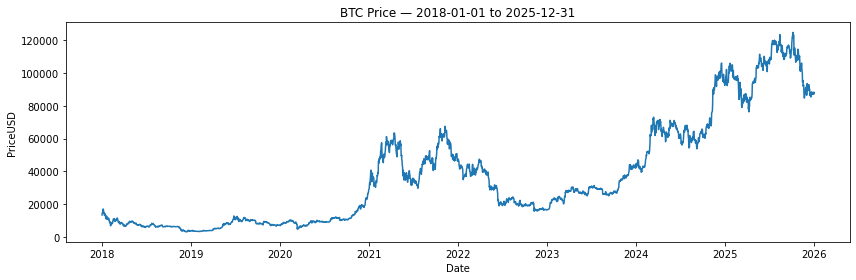

In [132]:
# Price Trend
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["PriceUSD"])
plt.title("BTC Price — 2018-01-01 to 2025-12-31")
plt.xlabel("Date")
plt.ylabel("PriceUSD")
plt.tight_layout()
plt.savefig("plots/BTC Price — 2018-01-01 to 2025-12-31.png", dpi=300, bbox_inches="tight")
plt.show()

# BTC 在样本期内经历了多轮明显的趋势行情（上涨-回撤-震荡-再上涨）。
# 后续做 cross-feature 分析时，我们要特别关注：不同周期里，预测市场/链上指标的关系是否一致，还是只在某些周期有效。

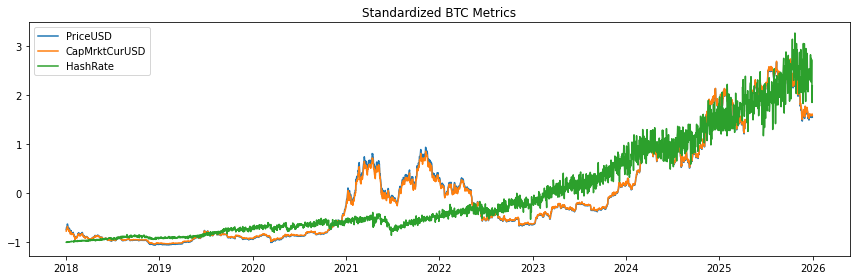

In [133]:
cols = ["PriceUSD", "CapMrktCurUSD", "HashRate"]
scaled = StandardScaler().fit_transform(df[cols])

plt.figure(figsize=(12,4))
plt.plot(df.index, scaled)
plt.legend(cols)
plt.title("Standardized BTC Metrics")
plt.tight_layout()
plt.savefig("plots/Standardized BTC Metrics.png", dpi=300)
plt.show()

# While BTC Price and Market Cap move almost identically due to their mechanical linkage, Hashrate reflects the underlying mining activity and network security.
# Unlike price, Hashrate demonstrates structural growth with cyclical adjustments, making it a more informative indicator of long-term network investment dynamics.

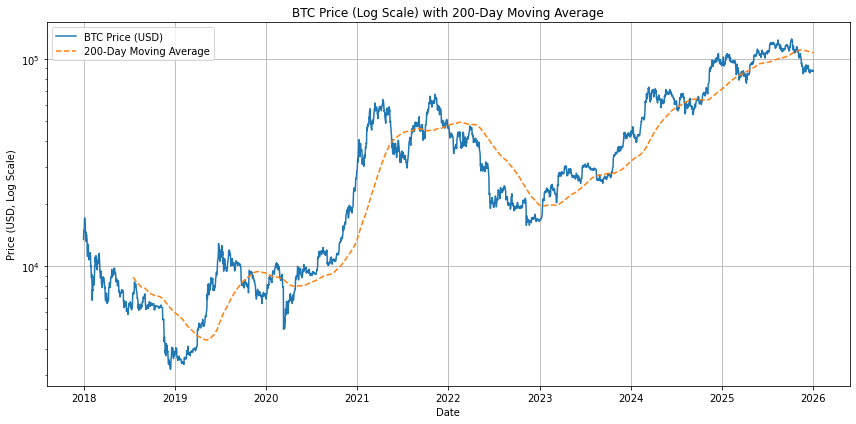

In [134]:
# BTC Price (Log Scale) with 200-Day Moving Average
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["PriceUSD"], label="BTC Price (USD)")
plt.plot(df.index, df["ma_200"], label="200-Day Moving Average", linestyle="--")

plt.yscale("log")

plt.title("BTC Price (Log Scale) with 200-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (USD, Log Scale)")

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("plots/BTC Price (Log Scale) with 200-Day Moving Average.png", dpi=300, bbox_inches="tight")
plt.show()

# 价格与 MA200 的关系呈现出典型的趋势切换：上穿后持续强势、跌破后更容易进入下行阶段。
# 这对积累策略很关键：如果我们之后发现 Polymarket 信号在“价格低于 MA200 或 drawdown 较深”时更有效，那就能形成更明确的使用场景（比如只在某些 regime 使用它）。

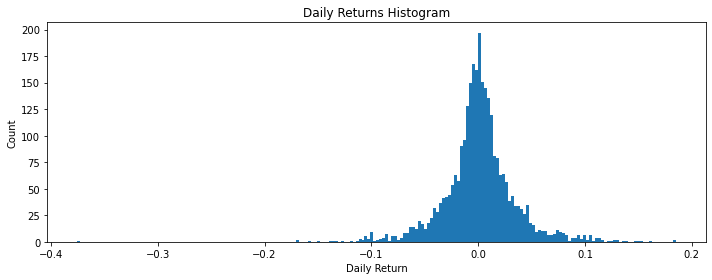

In [135]:
# Daily Profit Distribution
rets = df["ret_1d"].dropna()
plt.figure(figsize=(10, 4))
plt.hist(rets, bins=200)
plt.title("Daily Returns Histogram")
plt.xlabel("Daily Return")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("plots/Daily Returns Histogram.png", dpi=300, bbox_inches="tight")
plt.show()
# 日收益率呈现“集中在 0 附近 + 尾部较厚”的形态，说明极端波动并不少见。
# 这提醒我们：后续如果要做简单回归/相关性，不要只看均值，还要关注尾部时期（极端行情时预测市场是否更敏感）。

In [136]:
print("\nWorst 10 Days (ret_1d):")
print(rets.nsmallest(10))

print("\nBest 10 Days (ret_1d):")
print(rets.nlargest(10))


Worst 10 Days (ret_1d):
time
2020-03-12   -0.375350
2018-02-05   -0.169805
2022-06-13   -0.168244
2018-01-16   -0.158969
2022-11-09   -0.149165
2018-11-19   -0.137376
2019-06-27   -0.136329
2019-07-16   -0.133186
2021-01-21   -0.126495
2021-05-19   -0.120292
Name: ret_1d, dtype: float64

Best 10 Days (ret_1d):
time
2019-04-02    0.184926
2021-02-08    0.182522
2019-10-25    0.161286
2019-05-11    0.152202
2020-03-19    0.150406
2022-02-28    0.146409
2018-04-12    0.138168
2020-03-13    0.134772
2018-02-06    0.129804
2019-05-19    0.129398
Name: ret_1d, dtype: float64


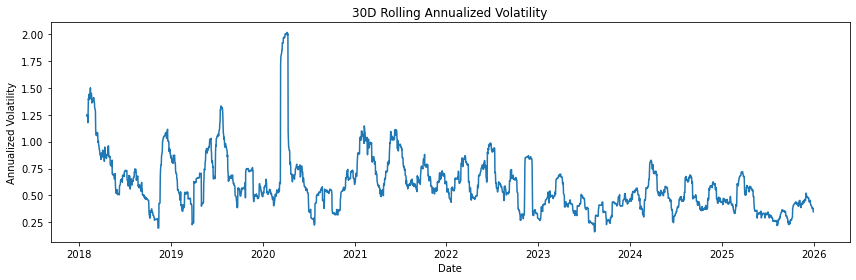

In [137]:
# 30D Rolling Annualized Volatility
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["vol_30d"])
plt.title("30D Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.tight_layout()
plt.savefig("plots/30D Rolling Annualized Volatility.png", dpi=300, bbox_inches="tight")
plt.show()
# BTC 的风险水平在不同阶段差异很大，高波动阶段往往成簇出现。
# 后续 cross-feature 分析可以问一个很有价值的问题：
# 预测市场价格/交易量是否在波动率上升前就出现变化？
# 如果有“领先”关系，那就是潜在的 accumulation timing 信号。

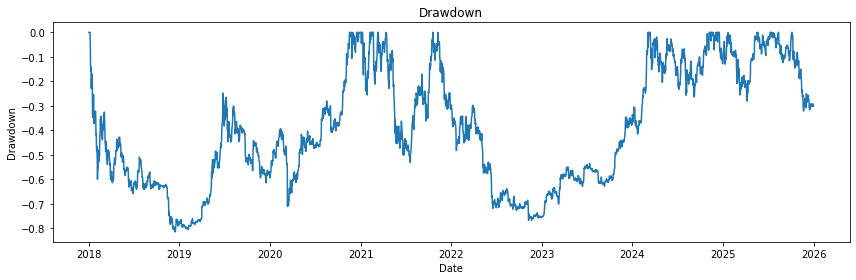

In [138]:
# Drawdown Plot
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["drawdown"])
plt.title("Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.tight_layout()
plt.savefig("plots/Drawdown.png", dpi=300, bbox_inches="tight")
plt.show()
# 样本期内存在多次深度回撤，符合 BTC 高风险高波动资产特征。
# 回撤指标可以作为“市场压力/折价”状态变量，后续可以用来分组分析：
# 比如 drawdown < -0.4（跌幅超过40%）时，Polymarket 的信号是否更有信息量。日收益率呈现“集中在 0 附近 + 尾部较厚”的形态，说明极端波动并不少见。

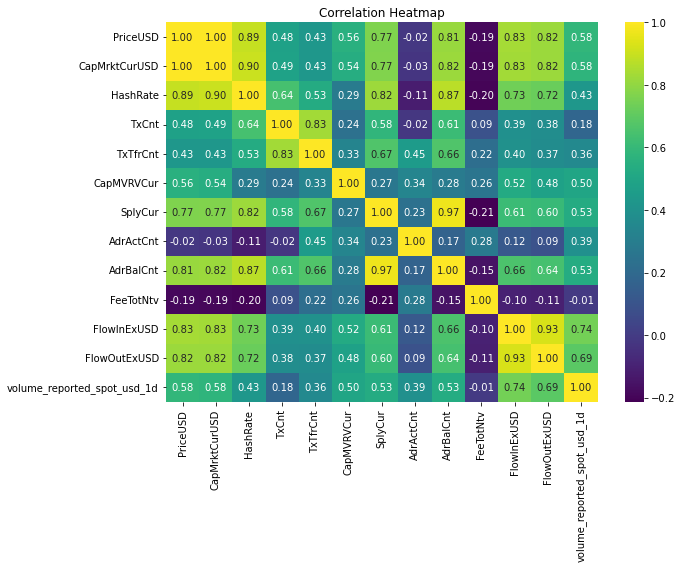

In [139]:
corr_cols = [
    "PriceUSD", "CapMrktCurUSD", "HashRate", "TxCnt", "TxTfrCnt",
    "CapMVRVCur", "SplyCur", "AdrActCnt", "AdrBalCnt",
    "FeeTotNtv", "FlowInExUSD", "FlowOutExUSD",
    "volume_reported_spot_usd_1d"
]
corr_cols = [c for c in corr_cols if c in df.columns]

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plots/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [140]:
# 相关矩阵显示，PriceUSD 与 CapMrktCurUSD 几乎完全正相关，符合市值由价格与供应量决定的机制关系。同时，SplyCur 与 AdrBalCnt 也高度相关，反映网络规模随时间累积增长。FlowInExUSD 与 FlowOutExUSD 呈强相关，说明市场活跃时交易所资金进出都会同步放大，因此净流（差值）可能更噪声。多数指标（如 HashRate、AdrBalCnt、FlowIn/Out）与价格相关性较高，可能主要体现牛熊周期趋势；相比之下，AdrActCnt 与价格相关性接近零，更可能提供相对独立的链上活动信息。MVRV 与价格呈中等相关，表明其既受价格影响，也可能包含一定估值层面的额外信息。

In [141]:
#Forward-looking performance conditioning analysis
# Build accumulation common metrics
# net inflow >0 means net outflow ，<0 means net inflow
df["net_flow_usd"] = df["FlowOutExUSD"] - df["FlowInExUSD"]

# PnL in next 30 days
h = 30
df["fwd_ret_30d"] = df["PriceUSD"].shift(-h) / df["PriceUSD"] - 1

# Forward vol in 30D log return
logret = np.log(df["PriceUSD"]).diff()
df["fwd_vol_30d"] = logret.shift(-1).rolling(h).std() * np.sqrt(365)

# Max Drawdown in next 30D
# Make the lowest price in the forward window, then convert to max drawdown
future_min_price = df["PriceUSD"].shift(-1).rolling(h).min()
df["fwd_min_dd_30d"] = future_min_price / df["PriceUSD"] - 1 

# Remove missing data in the last 30D
eda = df.dropna(subset=["fwd_ret_30d", "fwd_vol_30d", "fwd_min_dd_30d"]).copy()


In [142]:
#One dimensional bin analysis 
#Group into 5 binnings by MVRV
eda["mvrv_q5"] = pd.qcut(eda["CapMVRVCur"], 5, labels=[1,2,3,4,5])
mvrv_table = eda.groupby("mvrv_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n===  MVRV（CapMVRVCur）5 Buckets Grouping Result ===")
print(mvrv_table)



===  MVRV（CapMVRVCur）5 Buckets Grouping Result ===
  mvrv_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0       1  573         0.075359         0.054146         0.670342   
1       2  572         0.020615         0.000193         0.527412   
2       3  573         0.030614         0.012754         0.654079   
3       4  572         0.045156         0.012082         0.562571   
4       5  573         0.043455        -0.008083         0.601273   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.136126          0.001745  
1          0.092657          0.008741  
2          0.211169          0.050611  
3          0.164336          0.050699  
4          0.392670          0.184991  


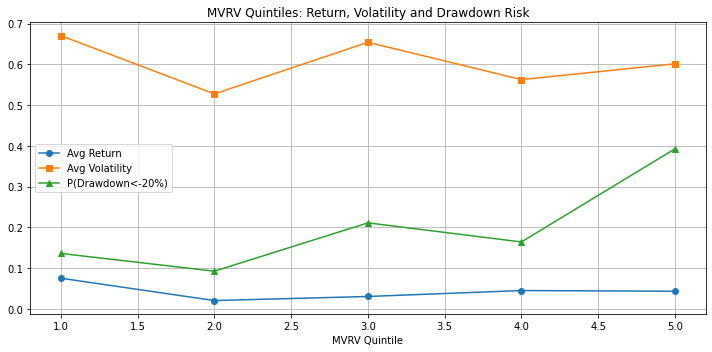

In [143]:
plt.figure(figsize=(10,5))

plt.plot(mvrv_table["mvrv_q5"], mvrv_table["avg_fwd_ret_30d"],
         marker="o", label="Avg Return")

plt.plot(mvrv_table["mvrv_q5"], mvrv_table["avg_fwd_vol_30d"],
         marker="s", label="Avg Volatility")

plt.plot(mvrv_table["mvrv_q5"], mvrv_table["prob_dd_lt_20pct"],
         marker="^", label="P(Drawdown<-20%)")

plt.legend()
plt.title("MVRV Quintiles: Return, Volatility and Drawdown Risk")
plt.xlabel("MVRV Quintile")
plt.grid(True)
plt.tight_layout()
plt.show()

# 当 MVRV 处于较低水平时（更像低估状态），未来30天的平均收益更高；说明 MVRV 在你的样本里对未来收益有一定“估值信号”的作用。
# MVRV越高，未来出现大回撤的概率越高，组5：未来30天跌超20%的概率约 39%，跌超30%的概率约 18.5%（很高）
# 低 MVRV 更像“机会”，高 MVRV 更像“风险”。因为高 MVRV 平均收益未必最低，但尾部下跌风险明显更大。

In [144]:
# Based on net_flow_usd group into 5
eda["netflow_q5"] = pd.qcut(eda["net_flow_usd"], 5, labels=[1,2,3,4,5])
netflow_table = eda.groupby("netflow_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n=== Net Flow (net_flow_usd) Quintile Binning Results ===")
print(netflow_table)


=== Net Flow (net_flow_usd) Quintile Binning Results ===
  netflow_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0          1  573         0.019433        -0.014197         0.624681   
1          2  572         0.044643         0.022561         0.616223   
2          3  573         0.052355         0.025048         0.620103   
3          4  572         0.061835         0.027716         0.610376   
4          5  573         0.037003         0.007718         0.544532   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.226876          0.099476  
1          0.187063          0.052448  
2          0.202443          0.043630  
3          0.201049          0.043706  
4          0.179756          0.057592  


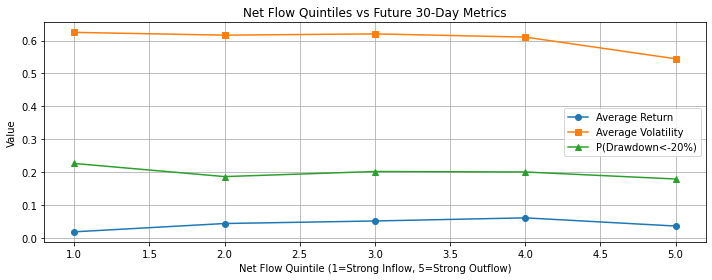

In [145]:
plt.figure(figsize=(10,4))

plt.plot(netflow_table["netflow_q5"],
         netflow_table["avg_fwd_ret_30d"],
         marker="o",
         label="Average Return")

plt.plot(netflow_table["netflow_q5"],
         netflow_table["avg_fwd_vol_30d"],
         marker="s",
         label="Average Volatility")

plt.plot(netflow_table["netflow_q5"],
         netflow_table["prob_dd_lt_20pct"],
         marker="^",
         label="P(Drawdown<-20%)")

plt.title("Net Flow Quintiles vs Future 30-Day Metrics")
plt.xlabel("Net Flow Quintile (1=Strong Inflow, 5=Strong Outflow)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("plots/Net Flow Quintiles vs 30-Day Metrics.png",
            dpi=300, bbox_inches="tight")

plt.show()

# 当资金更多流入交易所（净流入更强）时，未来30天发生大幅下跌的概率更高；而净流出更强时，未来大跌概率相对更低，说明净流向对“风险”有提示作用。
# 收益难预测，风险更容易被指标提示

In [146]:
#  AdrActCnt 5 binning
eda["adract_q5"] = pd.qcut(eda["AdrActCnt"], 5, labels=[1,2,3,4,5])
adr_table = eda.groupby("adract_q5").agg(
    n=("PriceUSD", "size"),
    avg_fwd_ret_30d=("fwd_ret_30d", "mean"),
    med_fwd_ret_30d=("fwd_ret_30d", "median"),
    avg_fwd_vol_30d=("fwd_vol_30d", "mean"),
    prob_dd_lt_20pct=("fwd_min_dd_30d", lambda x: (x < -0.20).mean()),
    prob_dd_lt_30pct=("fwd_min_dd_30d", lambda x: (x < -0.30).mean()),
).reset_index()

print("\n=== （AdrActCnt）Quintile Binning Results ===")
print(adr_table)


=== （AdrActCnt）Quintile Binning Results ===
  adract_q5    n  avg_fwd_ret_30d  med_fwd_ret_30d  avg_fwd_vol_30d  \
0         1  573         0.017177        -0.002325         0.630627   
1         2  572         0.021092         0.001985         0.569494   
2         3  573         0.059636         0.023675         0.613425   
3         4  572         0.042854         0.012553         0.584313   
4         5  573         0.074436         0.038444         0.617930   

   prob_dd_lt_20pct  prob_dd_lt_30pct  
0          0.101222          0.008726  
1          0.125874          0.045455  
2          0.211169          0.057592  
3          0.230769          0.055944  
4          0.328098          0.129145  


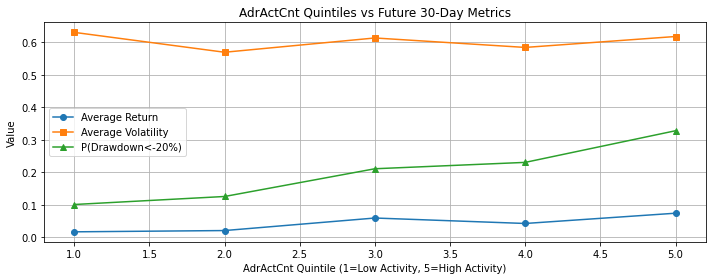

In [147]:
plt.figure(figsize=(10,4))

plt.plot(adr_table["adract_q5"],
         adr_table["avg_fwd_ret_30d"],
         marker="o",
         label="Average Return")

plt.plot(adr_table["adract_q5"],
         adr_table["avg_fwd_vol_30d"],
         marker="s",
         label="Average Volatility")

plt.plot(adr_table["adract_q5"],
         adr_table["prob_dd_lt_20pct"],
         marker="^",
         label="P(Drawdown<-20%)")

plt.title("AdrActCnt Quintiles vs Future 30-Day Metrics")
plt.xlabel("AdrActCnt Quintile (1=Low Activity, 5=High Activity)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("plots/AdrActCnt Quintiles vs 30-Day Metrics.png",
            dpi=300, bbox_inches="tight")

plt.show()
# 活跃地址数与未来波动率并不是简单的线性关系：在活跃度很低时，市场可能处于低流动性或压力状态，波动反而偏高；而活跃度很高时，市场交易更拥挤、情绪更强，也会带来更大的波动。因此 AdrActCnt 更像是反映“市场热度/拥挤程度”，而不是单方向的好坏信号。
# 同时表里也显示：
# AdrActCnt 越高，平均未来收益也偏高（Q5 avg_ret ≈ 7.4%）
# 但大回撤概率也更高（Q5 dd<-20% ≈ 32.8%）
# 所以：
# 高活跃可能意味着“机会更大，但风险也更大”。

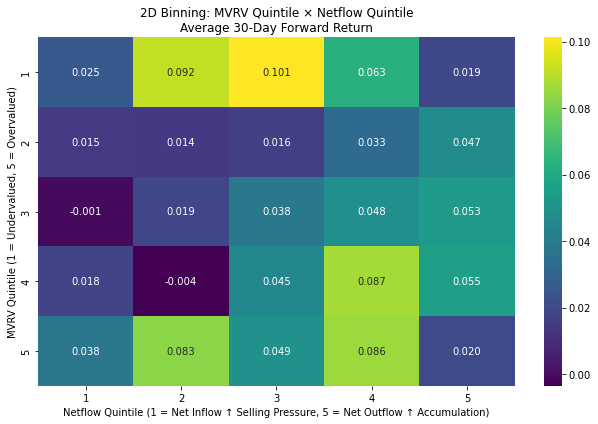

In [148]:
# 2D Binning: MVRV × Netflow
pivot = eda.pivot_table(
    index="mvrv_q5",
    columns="netflow_q5",
    values="fwd_ret_30d",
    aggfunc="mean"
)

plt.figure(figsize=(9,6))
sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

plt.title("2D Binning: MVRV Quintile × Netflow Quintile\nAverage 30-Day Forward Return")
plt.xlabel("Netflow Quintile (1 = Net Inflow ↑ Selling Pressure, 5 = Net Outflow ↑ Accumulation)")
plt.ylabel("MVRV Quintile (1 = Undervalued, 5 = Overvalued)")

plt.tight_layout()
plt.savefig("plots/2D Binning: MVRV Quintile × Netflow Quintile\nAverage 30-Day Forward Return.png", dpi=300, bbox_inches="tight")
plt.show()
# 当“估值(MVRV)”和“资金行为(Net Flow)”同时满足某种组合时，未来收益是否更好？
# MVRV = 1（低估） 且 Netflow 在中间偏高的组（2~3）
# # 未来30天平均收益最高（大约 0.092~0.101，也就是 9%~10%）。
# 二维分组结果显示，MVRV 与 Net Flow 结合时能更细分市场状态。整体上，低 MVRV（更像低估）配合某些净流状态时，未来30天平均收益更高（约 9%~10%），说明“估值 + 资金行为”的组合比只看单一指标更能区分未来表现。但同时也存在部分组合收益不理想甚至略为负值，表明这些指标对未来收益的解释并非完全稳定，可能受到市场周期等因素影响。

# 3. Polymarket data loading

In [149]:
#read polymarket data
import sys
import os
import polars as pl
#from pathlib import path

sys.path.append(os.path.abspath('..'))
# Import the loader from the template provided by the project
from eda_starter_template import load_polymarket_data, POLYMARKET_DIR

# Load the dictionary of DataFrames
poly_data_dict = load_polymarket_data(POLYMARKET_DIR)

# Extract individual DataFrames for easier use
if poly_data_dict:
    df_markets = poly_data_dict.get("markets")
    df_odds = poly_data_dict.get("odds")
    df_summary = poly_data_dict.get("summary")
    
    print("Data loaded successfully!")
else:
    print("Data directory not found. Check if the 'data/Polymarket' folder exists.")

Loading Polymarket data from /Users/shuangshuang/Documents/GitHub/bitcoin-analytics-capstone-sp26-team08/data/Polymarket...
[Memory] Before loading Polymarket data: 241.57 MB
Loaded 78321 markets.
Loaded 2143181 odds history records.
Loaded 78321 summary records.
[Memory] After loading Polymarket data: 414.58 MB (Δ 173.01 MB)
Data loaded successfully!


In [150]:
tokens_path = POLYMARKET_DIR / "finance_politics_tokens.parquet"
event_path = POLYMARKET_DIR / "finance_politics_event_stats.parquet"

df_tokens = (
    pl.scan_parquet(tokens_path)
    .collect()
)
df_event = (
    pl.scan_parquet(event_path)
    .collect()
)
# trades_path = POLYMARKET_DIR / "finance_politics_trades.parquet`"
# df_trades = (
#     pl.scan_parquet(trades_path)
#     .collect()
# )

In [151]:
df_markets.head()
df_markets
# Filter for rows where both are True
both_true = df_markets.filter(
    (pl.col("active") == True) & (pl.col("closed") == True)
)

print(f"Total Markets: {len(df_markets)}")
print(f"Markets with (active=True AND closed=True): {len(both_true)}")

Total Markets: 78321
Markets with (active=True AND closed=True): 73200


# 3.1 Markets

In [152]:
df_markets.head()

#find unique category
df_markets['category'].unique()
search_list = ["bitcoin", "btc","crypto","blockchain",'ETH']
# filter crypto related event, and general political event
crypto_markets = df_markets.filter(
    (pl.col("category").is_in([ "Crypto", "Business",'Politics'])) |
    (pl.col("question").str.contains_any(search_list, ascii_case_insensitive=True))
)

crypto_markets['category'].unique()

#check aggregated newly created daily market
daily_pm_features = (
    crypto_markets
    .filter(pl.col("created_at").is_not_null())
    .group_by(pl.col("created_at").dt.date().alias("date"))
    .agg([
        pl.count("market_id").alias("pm_new_market_count"),
        pl.col("volume").sum().alias("pm_daily_volume"),
        # average days the market remain active
        ((pl.col("end_date") - pl.col("created_at")).dt.total_days()).mean().alias("avg_market_duration")
    ])
    .sort("date")
)

# Convert to pandas 
#pm_features_pd = daily_pm_features.to_pandas()
pm_features_pd = pd.DataFrame(
    daily_pm_features.to_dict(as_series=False)
)
pm_features_pd['date'] = pd.to_datetime(pm_features_pd['date'])

# 

Correlation between BTC and Polymarket Activity:
                     PriceUSD   vol_30d  pm_new_market_count  pm_daily_volume
PriceUSD             1.000000 -0.538750             0.526379         0.449619
vol_30d             -0.538750  1.000000            -0.356751        -0.250236
pm_new_market_count  0.526379 -0.356751             1.000000         0.470874
pm_daily_volume      0.449619 -0.250236             0.470874         1.000000


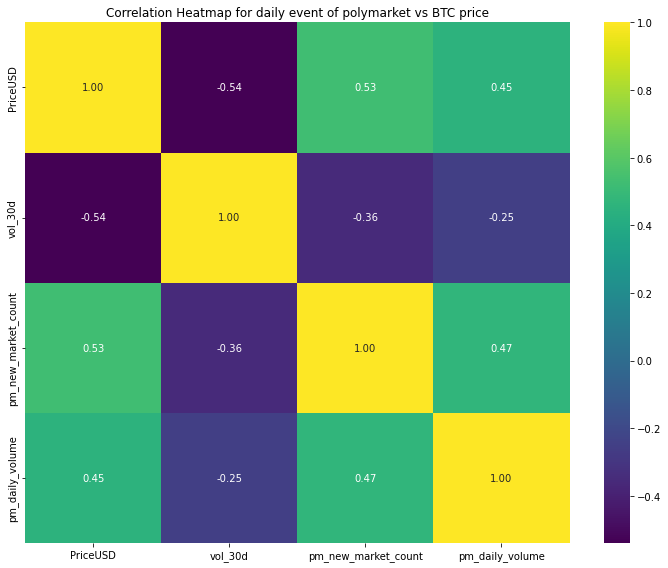

In [153]:
# combine markets with btc price data
btc_daily = eda.reset_index().rename(columns={'time':'date'})
btc_daily['date'] = btc_daily['date'].dt.normalize()

#merge the daily aggregated polymarket features with BTC price and vol
merged_markets_btc = btc_daily.merge(pm_features_pd,on='date',how='inner')

#correlation matrix
cols_to_corr = ['PriceUSD', 'vol_30d', 'pm_new_market_count', 'pm_daily_volume']
print("Correlation between BTC and Polymarket Activity:")
corr = merged_markets_btc[cols_to_corr].corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Heatmap for daily event of polymarket vs BTC price")
plt.tight_layout()
plt.show()

In [154]:
#investigate any lead lag relationship
merged_markets_btc['pm_count_lag1'] = merged_markets_btc['pm_new_market_count'].shift(1)

# Calculate correlation with Price Change (Returns) instead of absolute Price
merged_markets_btc['ret_1d'] = merged_markets_btc['PriceUSD'].pct_change()

lead_corr = merged_markets_btc[['ret_1d', 'pm_count_lag1']].corr()
print("Whether yesterday's PM activity predict today's BTC return?")
print(lead_corr)

Whether yesterday's PM activity predict today's BTC return?
                 ret_1d  pm_count_lag1
ret_1d         1.000000      -0.053154
pm_count_lag1 -0.053154       1.000000


Top 10 Macro Event Clusters by Volume:
shape: (10, 6)
┌─────────────────┬─────────────────┬─────────────────┬──────────┬────────────────┬────────────────┐
│ event_slug      ┆ total_event_vol ┆ sub_market_coun ┆ %_active ┆ start_date     ┆ end_date       │
│ ---             ┆ ume             ┆ t               ┆ ---      ┆ ---            ┆ ---            │
│ str             ┆ ---             ┆ ---             ┆ f64      ┆ datetime[μs]   ┆ datetime[μs]   │
│                 ┆ f64             ┆ u32             ┆          ┆                ┆                │
╞═════════════════╪═════════════════╪═════════════════╪══════════╪════════════════╪════════════════╡
│ presidential-el ┆ 3.6863e9        ┆ 17              ┆ 1.0      ┆ 2024-01-04     ┆ 2024-11-05     │
│ ection-winner-2 ┆                 ┆                 ┆          ┆ 17:33:51       ┆ 12:00:00       │
│ …               ┆                 ┆                 ┆          ┆                ┆                │
│ presidential-el ┆ 6.2816e8        ┆

/var/folders/85/jcyy_w7d4g5cdzprsfn0tngh0000gn/T/ipykernel_9041/1506080471.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_clusters_pd, x="total_event_volume", y="event_slug", palette="viridis")


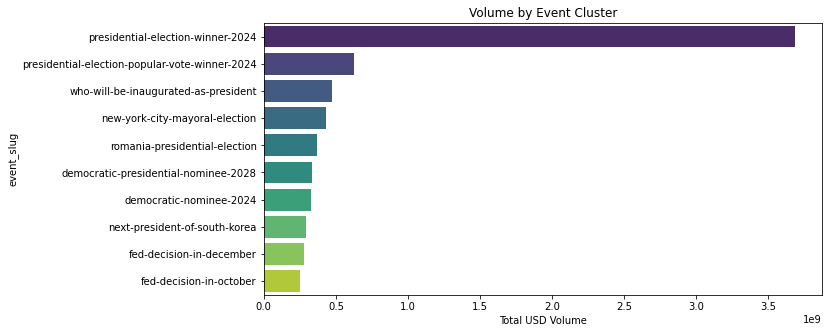

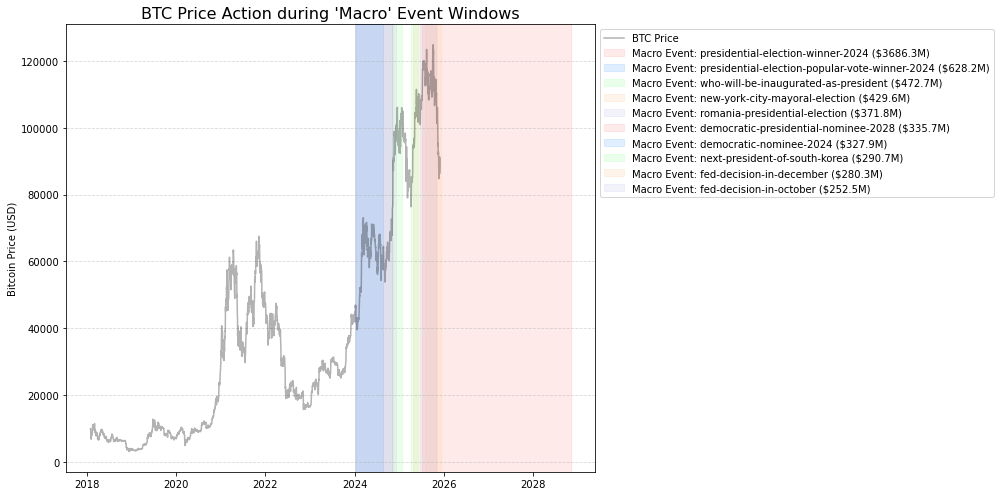

In [155]:
# Check event slug level
#1 event cluster shows election tops the chart (as expected)
event_clusters = (
    df_markets
    .group_by("event_slug")
    .agg([
        pl.col("volume").sum().alias("total_event_volume"),
        pl.count("market_id").alias("sub_market_count"),
        pl.col("active").mean().alias("%_active"),
        pl.col("created_at").min().alias("start_date"),
        pl.col("end_date").max().alias("end_date")
    ])
    .sort("total_event_volume", descending=True)
    .head(10) 
)

print("Top 10 Macro Event Clusters by Volume:")
print(event_clusters)

# Visualization of Event Clusters
event_clusters_pd = pd.DataFrame(event_clusters.to_dict(as_series=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=event_clusters_pd, x="total_event_volume", y="event_slug", palette="viridis")
plt.title("Volume by Event Cluster")
plt.xlabel("Total USD Volume")
plt.show()

#2 plot BTC price
plt.figure(figsize=(14, 7))

# Plot BTC Price
plt.plot(btc_daily['date'], btc_daily['PriceUSD'], color='black', alpha=0.3, label='BTC Price')
plt.ylabel("Bitcoin Price (USD)")

#3 overlay the cluster, check btc movement during big macro event
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99', '#c2c2f0']

for i, row in enumerate(event_clusters.to_dicts()):
    # Convert to pandas timestamps for plotting
    start = pd.to_datetime(row['start_date'])
    end = pd.to_datetime(row['end_date'])
    
    # Shade the area where this Macro event was active
    plt.axvspan(start, end, alpha=0.2, color=colors[i % len(colors)], 
                label=f"Macro Event: {row['event_slug']} (${row['total_event_volume']/1e6:.1f}M)")

plt.title("BTC Price Action during 'Macro' Event Windows", fontsize=16)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

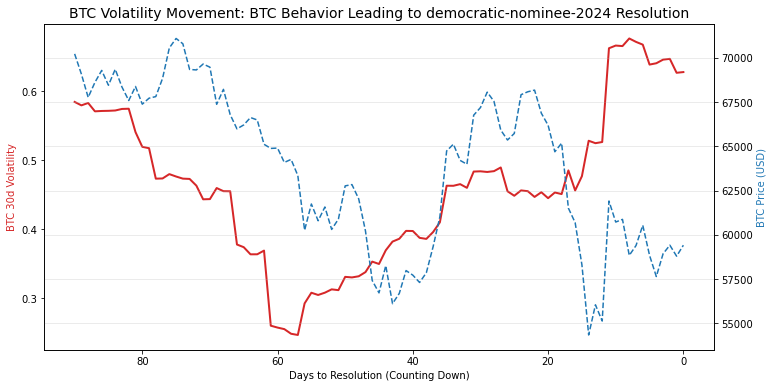

In [156]:
#Check volatility change when event approaches the end

major_slug = event_clusters['event_slug'][6] 

magnet_markets = df_markets.filter(pl.col("event_slug") == major_slug)

# 2. Calculate "Days to Resolution" for each day in history
# We join the BTC daily dates with the event's end date
resolution_date = magnet_markets['end_date'].max()

btc_pressure = btc_daily.copy()
btc_pressure['days_to_res'] = (pd.to_datetime(resolution_date) - pd.to_datetime(btc_pressure['date'])).dt.days

# Filter to only show the 90 days leading up to the resolution
btc_pressure = btc_pressure[(btc_pressure['days_to_res'] >= 0) & (btc_pressure['days_to_res'] <= 90)]

# 3. Plot Volatility vs Countdown
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Days to Resolution (Counting Down)')
ax1.set_ylabel('BTC 30d Volatility', color='tab:red')
ax1.plot(btc_pressure['days_to_res'], btc_pressure['vol_30d'], color='tab:red', linewidth=2)
ax1.invert_xaxis() # Countdown from 90 to 0

ax2 = ax1.twinx()
ax2.set_ylabel('BTC Price (USD)', color='tab:blue')
ax2.plot(btc_pressure['days_to_res'], btc_pressure['PriceUSD'], color='tab:blue', linestyle='--')

plt.title(f"BTC Volatility Movement: BTC Behavior Leading to {major_slug} Resolution", fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# 3.2 Tokens

In [157]:
df_tokens

market_id,token_id,outcome
str,str,str
"""240383""","""555875344331027638590324435858…","""Yes"""
"""240383""","""111837615529992437689409005124…","""No"""
"""240384""","""113459643164060403919504712048…","""Yes"""
"""240384""","""110606609354376812966157988257…","""No"""
"""240385""","""505435736314143687770680977181…","""Yes"""
…,…,…
"""892920""","""496224936867145107714728324950…","""Down"""
"""892921""","""116918525891988714423444796180…","""Up"""
"""892921""","""827298723842613390623635576167…","""Down"""


In [158]:
df_tokens.select("outcome").unique()

outcome
str
"""Lajal"""
"""Rollins"""
"""Democratic"""
"""Tsitsipas"""
"""Coalition"""
…
"""Sinner"""
"""Khachanov"""
"""Stelson"""


# 3.4 Odds History

In [159]:
df_odds = df_odds.with_columns(
    pl.col("timestamp").dt.date().alias("date")
)

df_odds.head()

market_id,token_id,timestamp,price,date
str,str,datetime[μs],f64,date
"""255140""","""474357953615233060686693901910…",2024-06-08 00:00:02,0.055,2024-06-08
"""255140""","""474357953615233060686693901910…",2024-06-09 00:00:03,0.055,2024-06-09
"""255140""","""474357953615233060686693901910…",2024-06-10 00:00:04,0.055,2024-06-10
"""255140""","""474357953615233060686693901910…",2024-06-11 00:00:02,0.055,2024-06-11
"""255140""","""474357953615233060686693901910…",2024-06-12 00:00:03,0.055,2024-06-12


In [160]:
df_tokens_simple = (
    df_tokens
    .with_columns(pl.col("outcome").str.to_lowercase().alias("outcome_lower"))
    .filter(
        pl.col("outcome_lower").is_in(["yes", "no", "up", "down"])
    )
)

In [161]:
df_odds_simple = df_odds.join(
    df_tokens_simple.select(["market_id", "token_id", "outcome"]),
    on=["market_id", "token_id"],
    how="inner"
)

df_odds_simple.head()

market_id,token_id,timestamp,price,date,outcome
str,str,datetime[μs],f64,date,str
"""255140""","""474357953615233060686693901910…",2024-06-08 00:00:02,0.055,2024-06-08,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-09 00:00:03,0.055,2024-06-09,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-10 00:00:04,0.055,2024-06-10,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-11 00:00:02,0.055,2024-06-11,"""Yes"""
"""255140""","""474357953615233060686693901910…",2024-06-12 00:00:03,0.055,2024-06-12,"""Yes"""


In [162]:
df_daily = (
    df_odds_simple
    .sort(["market_id", "date", "timestamp"])
    .group_by(["market_id", "date"])
    .agg([
        pl.col("price").last().alias("p_close"),
        pl.count().alias("update_count")
    ])
    .sort(["market_id", "date"])
)

df_daily = df_daily.with_columns(
    (pl.col("p_close") - pl.col("p_close").shift(1))
    .over("market_id")
    .alias("p_diff_1d")
)

df_daily = df_daily.with_columns(
    pl.col("p_diff_1d")
    .rolling_std(7)
    .over("market_id")
    .alias("p_vol_7d")
)

/var/folders/85/jcyy_w7d4g5cdzprsfn0tngh0000gn/T/ipykernel_9041/84762546.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("update_count")


In [163]:
df_daily.describe()

statistic,market_id,date,p_close,update_count,p_diff_1d,p_vol_7d
str,str,str,f64,f64,f64,f64
"""count""","""785733""","""785733""",785733.0,785733.0,728826.0,574131.0
"""null_count""","""0""","""0""",0.0,0.0,56907.0,211602.0
"""mean""",null,"""2025-05-03 11:34:47.211304""",0.506833,2.711594,0.000243,0.399436
"""std""",null,null,0.397911,5.15958,0.446806,0.281403
"""min""","""248385""","""2023-01-24""",0.0005,1.0,-0.999,0.0
"""25%""",null,"""2024-11-23""",0.065,2.0,-0.0075,0.098652
"""50%""",null,"""2025-07-21""",0.5,2.0,0.0,0.418189
"""75%""",null,"""2025-10-29""",0.9435,2.0,0.008,0.625738
"""max""","""905434""","""2026-01-05""",1.0,50.0,0.999,1.067976


In [164]:
daily_index = (
    df_daily
    .group_by("date")
    .agg([
        pl.col("p_vol_7d").mean().alias("risk_index"),
        pl.col("p_diff_1d").mean().alias("prob_shift_index"),
        pl.col("update_count").mean().alias("attention_index"),
        pl.count().alias("num_markets")
    ])
    .sort("date")
)

/var/folders/85/jcyy_w7d4g5cdzprsfn0tngh0000gn/T/ipykernel_9041/1281110981.py:8: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("num_markets")


In [165]:
daily_pd = pd.DataFrame(daily_index.to_dict(as_series=False))

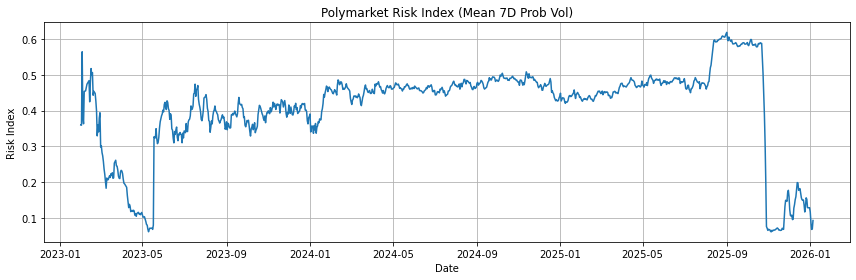

In [166]:
plt.figure(figsize=(12,4))
plt.plot(daily_pd["date"], daily_pd["risk_index"])
plt.title("Polymarket Risk Index (Mean 7D Prob Vol)")
plt.xlabel("Date")
plt.ylabel("Risk Index")
plt.grid(True)
plt.tight_layout()
plt.show()

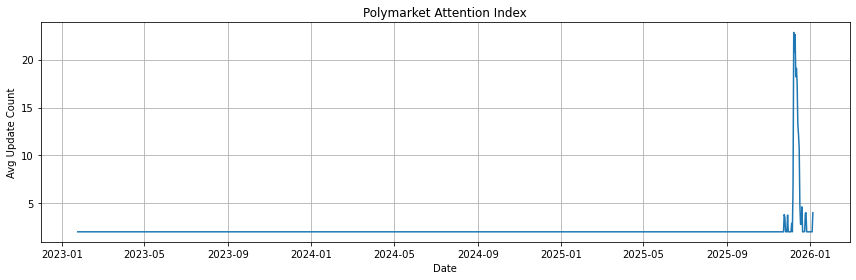

In [167]:
plt.figure(figsize=(12,4))
plt.plot(daily_pd["date"], daily_pd["attention_index"])
plt.title("Polymarket Attention Index")
plt.xlabel("Date")
plt.ylabel("Avg Update Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [168]:
btc_pd = df.reset_index()[["time", "PriceUSD"]]
daily_pd["date"] = pd.to_datetime(daily_pd["date"]).dt.normalize()
btc_pd["time"] = pd.to_datetime(btc_pd["time"]).dt.normalize()

merged = daily_pd.merge(
    btc_pd,
    left_on="date",
    right_on="time",
    how="inner"
)

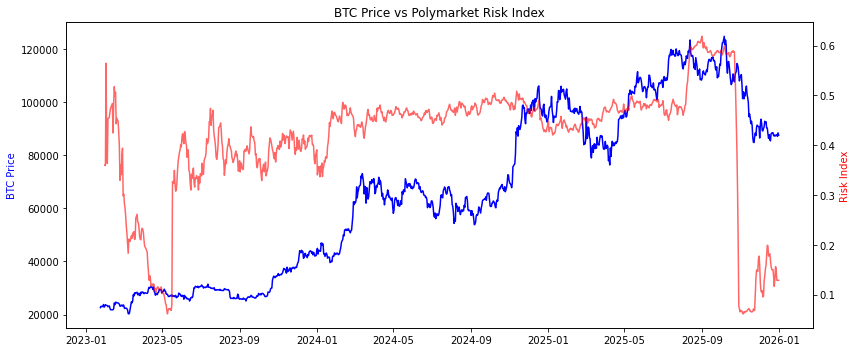

In [169]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(merged["date"], merged["PriceUSD"], color="blue")
ax1.set_ylabel("BTC Price", color="blue")

ax2 = ax1.twinx()
ax2.plot(merged["date"], merged["risk_index"], color="red", alpha=0.6)
ax2.set_ylabel("Risk Index", color="red")

plt.title("BTC Price vs Polymarket Risk Index")
plt.tight_layout()
plt.show()

In [170]:
#分箱分析
merged["risk_q5"] = pd.qcut(merged["risk_index"], 5, labels=[1,2,3,4,5])

risk_table = merged.groupby("risk_q5").agg(
    avg_btc_price=("PriceUSD","mean")
)

print(risk_table)

         avg_btc_price
risk_q5               
1         49031.934122
2         43092.312702
3         72559.436956
4         77500.317864
5         94019.763779


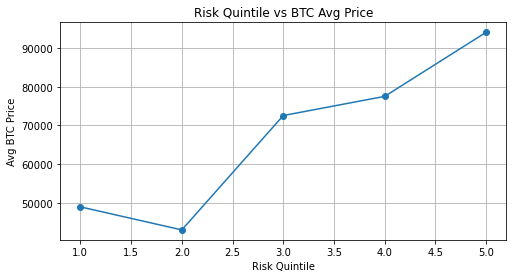

In [171]:
plt.figure(figsize=(8,4))
plt.plot(risk_table.index, risk_table["avg_btc_price"], marker="o")
plt.title("Risk Quintile vs BTC Avg Price")
plt.xlabel("Risk Quintile")
plt.ylabel("Avg BTC Price")
plt.grid(True)
plt.show()